# ML - bu komyuterga aniq qoidalar yozmasdan , malumotlardan o`rganish imkonini beradigan soha
- SML 
- UNS ML 
- RE ML 

# ARL - association rule learning -- ARL malumotlar ichidan agarda A bo`lsa B ham bo`ladi degan qaror qabul qiladi ya`ni boglanishlarni aniqlash tizimi

# Non olgan odam Sut olishi extimoli 80 % 

# ARL ning asosiy tushunchalari 

| Metric     | Ma’nosi                    |
| ---------- | -------------------------- |
| Support    | qanchalik tez-tez uchraydi |
| Confidence | ehtimollik                 |
| Lift       | bog‘liqlik kuchi           |


# SML, UNSML, ARL ni taqqoslash   

| Xususiyat   | SL               | UNS    | ARL         |
| ----------- | ---------------- | ------ | ----------- |
| Label bor   | ✅                | ❌      | ❌           |
| Maqsad      | Predict          | Group  | Rule topish |
| Algoritmlar | Logistic, Linear | KMeans | Apriori     |


# ARL bu REC SYS ning miya si asosiy qismi hisoblanad
- ARL qoidlarni topadi -- malumotlar ichidan bog`liqliklarni aniqlaydi MIlk- Bread 
- rec sys nima  qiladi - keyin nima olishi mumkin degan savolga javob topadi 
- ARL topgan qoidalar - rec sys ishlatadigan knowledge bo`ladi 

# data yi`giladi 
User1: Milk, Bread
User2: Milk, Butter

# ARL ishladi 

Milk  -->  Bread (Confidence = 0.8)
Milk -- > Butter (Confidence = 0.6)

# REC SYS ishladi 

Agar User Milk sotib olsa unga 

--> bread tavsiya qiladi 
--> butter tavsiya qiladi

# ARL da ishlatilinadigan algaritmlar 
| Algoritm       | Tavsifi                                                                              | Afzalligi                              | Kamchiligi                                                      |
| -------------- | ------------------------------------------------------------------------------------ | -------------------------------------- | --------------------------------------------------------------- |
| **Apriori**    | Ma’lumotlar ichidagi frequent itemsetlarni topadi va ularni qoida shaklida chiqaradi | Oddiy, tushunarli                      | Katta datasetda sekin, barcha candidate itemsetlarni tekshiradi |
| **Eclat**      | Frequent itemsetlarni **vertical format** yordamida topadi                           | Tezroq, kam xotira talab qiladi        | Murakkab, tushunishi qiyin                                      |
| **FP-Growth**  | **Frequent Pattern Tree** orqali itemsetlarni topadi, candidate list ishlatilmaydi   | Juda tez va katta dataset uchun yaxshi | Kodlash biroz murakkab, tushunarli emas                         |
| **AIS / SETM** | Early ARL algoritmlari, real-time market basket analysis uchun                       | Streaming data bilan ishlaydi          | Kam ishlatiladi, eski algoritmlar                               |


# APRIORY ning asosiy maqsadi -- kim nima olgan --> yana nima olishi mumkin

- Apriori algoritm printsipi
- 1-itemsetlarni tekshirish → min_support’dan katta bo‘lgan itemlarni saqlash
- 2-itemsetlarni yaratish → 1-itemsetlarni kombinatsiya qilib tekshirish
- 3-itemsetlar va yuqorilar → shunday davom ettirish
- Confidence va Lift hisoblash → qoidalarni chiqarish

| Termin         | Ma’nosi                                                  |
| -------------- | -------------------------------------------------------- |
| **Support**    | Item yoki itemset qancha tez-tez uchraydi                |
| **Confidence** | “A bo‘lsa B ham bo‘ladi” ehtimoli                        |
| **Lift**       | Haqiqiy bog‘liqlik kuchi, >1 bo‘lsa mustahkam bog‘lanish |


# Ixtiyoriy dataset 
| TransactionID | Items               |
| ------------- | ------------------- |
| 1             | Milk, Bread         |
| 2             | Milk, Butter        |
| 3             | Bread, Butter       |
| 4             | Milk, Bread, Butter |
| 5             | Bread               |
| 6             | Milk, Bread         |


In [1]:
!pip install pandas mlxtend

  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl (9.7 MB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.8 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached scipy-1.17.1-cp313-cp313-win_amd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Datani tayyorlash

In [2]:
import pandas as pd 
from mlxtend.preprocessing import TransactionEncoder

#datset
dataset = [
    ['Milk', 'Bread'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread'],
    ['Milk', 'Bread'],
]

# transaction encoder yordamida raqamli korinishga otkazamiz 

te = TransactionEncoder()
te_data = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_data, columns=te.columns_)

print(df)

   Bread  Butter   Milk
0   True   False   True
1  False    True   True
2   True    True  False
3   True    True   True
4   True   False  False
5   True   False   True


# frequent itemslarni topish 

In [3]:
from mlxtend.frequent_patterns import apriori 

# min_support = 0.5 itemset kamida 50 % tranzaksiyada bo`lishi kerak 
frequent_items = apriori(df, min_support=0.5, use_colnames=True)
print(frequent_items)

    support                  itemsets
0  0.833333        frozenset({Bread})
1  0.500000       frozenset({Butter})
2  0.666667         frozenset({Milk})
3  0.500000  frozenset({Milk, Bread})


# Association Rule chiqarish 

In [4]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric = "confidence", min_threshold=0.6)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

          antecedents         consequents  support  confidence  lift
0   frozenset({Milk})  frozenset({Bread})      0.5        0.75   0.9
1  frozenset({Bread})   frozenset({Milk})      0.5        0.60   0.9


# Natija taxlili --> Milk >> Bread == confidence = 0.75 chiqdi demak agar mijoz milk olsa 75 & ehtimol bilan bread ham oladi, Lift = 0.9 degani bu bo`gliqlik kuchi 

# Real use case (Recommendation)

In [5]:
def recommend(product):
    result = rules[rules['antecedents'].apply(lambda x: product in x)]
    return result[["consequents", 'confidence']]

print(recommend('Milk'))

          consequents  confidence
0  frozenset({Bread})        0.75


# Real dataset bilan kichik amaliyot

In [7]:
!pip install pandas  mlxtend seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import seaborn as sns
import pandas as pd  

df = sns.load_dataset("tips")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


In [10]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
df = df[['sex', 'smoker', 'day', 'time']]

# har bir row ni transactionga aylantirish 
transactions = df.astype(str).values.tolist()

print(transactions[:5])

[['Female', 'No', 'Sun', 'Dinner'], ['Male', 'No', 'Sun', 'Dinner'], ['Male', 'No', 'Sun', 'Dinner'], ['Male', 'No', 'Sun', 'Dinner'], ['Female', 'No', 'Sun', 'Dinner']]


In [13]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_data, columns=te.columns_)
print(basket.head())

   Dinner  Female    Fri  Lunch   Male    No    Sat   Sun   Thur    Yes
0    True    True  False  False  False  True  False  True  False  False
1    True   False  False  False   True  True  False  True  False  False
2    True   False  False  False   True  True  False  True  False  False
3    True   False  False  False   True  True  False  True  False  False
4    True    True  False  False  False  True  False  True  False  False


In [14]:
from mlxtend.frequent_patterns import apriori
frequent_items = apriori(basket, min_support=0.1, use_colnames=True)
print(frequent_items.sort_values(by="support", ascending=False))

     support                             itemsets
0   0.721311                  frozenset({Dinner})
3   0.643443                    frozenset({Male})
4   0.618852                      frozenset({No})
10  0.508197            frozenset({Dinner, Male})
11  0.434426              frozenset({Dinner, No})
23  0.397541                frozenset({No, Male})
8   0.381148                     frozenset({Yes})
5   0.356557                     frozenset({Sat})
12  0.356557             frozenset({Dinner, Sat})
1   0.356557                  frozenset({Female})
34  0.315574        frozenset({Dinner, No, Male})
13  0.311475             frozenset({Sun, Dinner})
6   0.311475                     frozenset({Sun})
14  0.286885             frozenset({Dinner, Yes})
2   0.278689                   frozenset({Lunch})
7   0.254098                    frozenset({Thur})
22  0.250000             frozenset({Lunch, Thur})
27  0.245902               frozenset({Male, Yes})
24  0.241803               frozenset({Sat, Male})


In [15]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric = "confidence", min_threshold=0.5)
rules = rules.sort_values(by="confidence", ascending=False)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                 antecedents                 consequents   support  \
5           frozenset({Sat})         frozenset({Dinner})  0.356557   
6           frozenset({Sun})         frozenset({Dinner})  0.311475   
40      frozenset({Sat, No})         frozenset({Dinner})  0.184426   
34    frozenset({Sun, Male})         frozenset({Dinner})  0.237705   
31    frozenset({Sat, Male})         frozenset({Dinner})  0.241803   
..                       ...                         ...       ...   
8         frozenset({Lunch})         frozenset({Female})  0.143443   
29           frozenset({No})   frozenset({Dinner, Male})  0.315574   
50  frozenset({Lunch, Thur})         frozenset({Female})  0.127049   
38          frozenset({Yes})   frozenset({Dinner, Male})  0.192623   
53         frozenset({Thur})  frozenset({Lunch, Female})  0.127049   

    confidence      lift  
5     1.000000  1.386364  
6     1.000000  1.386364  
40    1.000000  1.386364  
34    1.000000  1.386364  
31    1.000000  1.386364

In [16]:
def recommend(item):
    result = rules[rules['antecedents'].apply(lambda x: item in x)]
    return result[['consequents', 'confidence']]

print(recommend('Dinner'))

              consequents  confidence
33      frozenset({Male})    0.763158
74      frozenset({Male})    0.754386
42        frozenset({No})    0.750000
75        frozenset({No})    0.741379
26      frozenset({Male})    0.726415
70      frozenset({Male})    0.711111
1       frozenset({Male})    0.704545
30      frozenset({Male})    0.678161
36      frozenset({Male})    0.671429
82      frozenset({Male})    0.642857
27        frozenset({No})    0.620968
3         frozenset({No})    0.602273
46       frozenset({Sat})    0.600000
83       frozenset({Sat})    0.574468
78  frozenset({No, Male})    0.565789
77       frozenset({Sun})    0.558442
22        frozenset({No})    0.557692
69        frozenset({No})    0.542373
24       frozenset({Sat})    0.538462
44       frozenset({Sun})    0.537736
39        frozenset({No})    0.517241


# Multi item recommendation

In [19]:
def recommend_multiple(items):
    result = rules[rules['antecedents'].apply(lambda x:  all (i in x for i in items))]
    return result[['consequents', 'confidence']]

print(recommend_multiple(['Dinner', 'Male']))

         consequents  confidence
75   frozenset({No})    0.741379
27   frozenset({No})    0.620968
83  frozenset({Sat})    0.574468
77  frozenset({Sun})    0.558442
69   frozenset({No})    0.542373


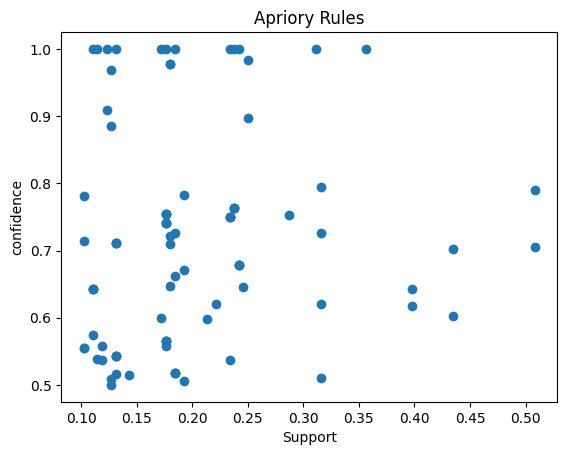

In [20]:
import matplotlib.pyplot as plt 

plt.scatter(rules['support'], rules["confidence"])
plt.xlabel("Support")
plt.ylabel("confidence")
plt.title("Apriory Rules")
plt.show()